# Atari Games - Space Invaders

The mission is to build an AI that "plays" Atari video games. I need to build 3 diffeent models that solve three different Atari games. This notebook is for the second game called Space Invaders. The subject asks for using reinforcement learning and Deep Q-networks.

## Table of contents:
* [Imports](#imports)
* [Model training](#training)
* [Training evaluation](#training_evaluation)

## Imports <a class="anchor" id="imports"></a>

In [19]:
import ale_py
import numpy as np
import pandas as pd
import gymnasium as gym
import matplotlib.pyplot as plt


from datetime import datetime
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from my_atari_helpers import make_env, EpisodicReturnCallback, plot_training

In [2]:
SEED = 142
np.random.seed(SEED)
gym.register_envs(ale_py)
plt.rcParams["figure.figsize"] = (10, 5)
ENV_ID = "SpaceInvadersNoFrameskip-v4"

## Model training <a class="anchor" id="training"></a>

In [5]:
dqn_kwargs = {
    "buffer_size": 10_000,
    "learning_rate": 1e-6,
    "batch_size": 32,
    "learning_starts": 1000,
    "target_update_interval": 100,
    "train_freq": 4,
    "gradient_steps": 1,
    "gamma": 0.99
}

train_env = make_env(ENV_ID, SEED, 8)
model = DQN("CnnPolicy", train_env, **dqn_kwargs)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


## Train

In [6]:
%%time
TOTAL_TIMESTAMPS = 1_500_000
log_cb = EpisodicReturnCallback()
model.learn(total_timesteps=TOTAL_TIMESTAMPS, callback=log_cb)

CPU times: user 2h 1min 33s, sys: 15min 37s, total: 2h 17min 10s
Wall time: 56min 38s


In [7]:
model.save(f"models/space_invaders/space_invaders_model_{TOTAL_TIMESTAMPS}_steps_{datetime.now().strftime("%Y-%m-%dT%H:%M:%S")}")

## Training evaluation <a class="anchor" id="training_evaluation"></a>

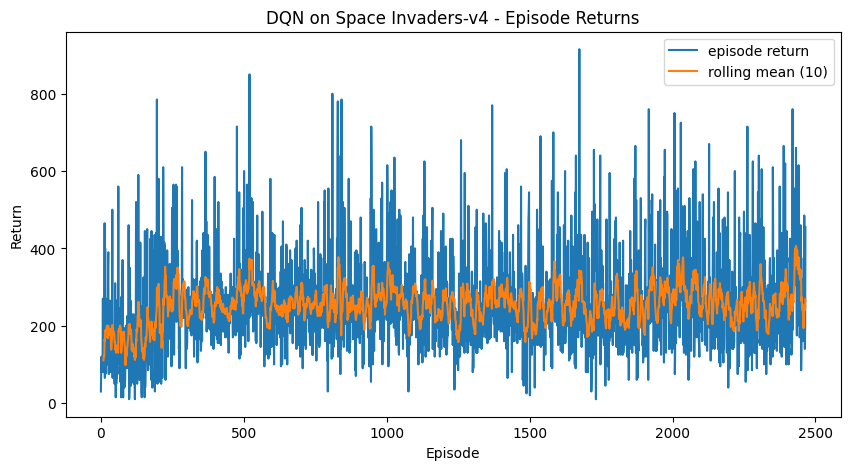

In [20]:
plot_training(log_cb.episode_returns, 10)

In [10]:
mean_train_reward = np.mean(log_cb.episode_returns)
print(f"Mean train reward: {np.mean(log_cb.episode_returns)}")

Mean train reward: 253.9720194647202


In [11]:
n_eval_episodes = 50
mean_eval_reward, _ = evaluate_policy(
    model,
    make_env(ENV_ID, SEED, 8),
    n_eval_episodes=n_eval_episodes,
    deterministic=True
)

print(f"Mean eval reward: {mean_eval_reward}")

Mean eval reward: 477.1


In [16]:
eval_params = pd.read_csv("space_invaders_experiments_params.csv")

In [17]:
new_training_data = pd.DataFrame([dqn_kwargs]) 
new_training_data["training_round"] = 32
new_training_data = new_training_data.iloc[:, [8, 0, 1, 2, 3, 4, 5, 6, 7]]
new_training_data["n_timestamps"] = TOTAL_TIMESTAMPS
new_training_data["mean_train_returns"] = mean_train_reward
new_training_data["mean_eval_returns"] = mean_eval_reward
new_training_data["n_eval_episodes"] = n_eval_episodes
new_training_data["time_to_train"] = "56:38 mins"
eval_params = pd.concat([eval_params, new_training_data])
eval_params.tail(5)

,training_round,buffer_size,learning_rate,batch_size,learning_starts,target_update_interval,train_freq,gradient_steps,gamma,n_timestamps,mean_train_returns,mean_eval_returns,n_eval_episodes,time_to_train
27,28,10000,0.000001,32,1000,100,4,1,0.99,1500000,265.000000,379.0,20.0,1:38:00 h
28,29,10000,0.000001,32,10000,1000,4,1,0.99,500000,238.000000,225.0,20.0,18:00 mins
29,30,100000,0.000001,32,10000,1000,4,1,0.99,500000,200.000000,271.0,20.0,18:00 mins
30,31,25500,0.000003,32,5700,100,4,1,0.99,500000,233.000000,301.0,20.0,18:00 mins
0,32,10000,0.000001,32,1000,100,4,1,0.99,1500000,253.972019,477.1,50.0,56:38 mins


In [18]:
eval_params.to_csv("space_invaders_experiments_params.csv", index=False)

## Hyperparameter analysis

In [17]:
import math

def halton(index, base):
    result = 0
    f = 1 / base
    i = index
    while i > 0:
        result += f * (i % base)
        i = i // base
        f = f / base
    return result


def log_uniform(h, low, high):
    return math.exp(math.log(low) + h * (math.log(high) - math.log(low)))


def uniform(h, low, high):
    return low + h * (high - low)


def generate_dqn_experiments(n=30, start_index=1):
    """
    3D Halton sweep:
    - learning_rate: [1e-7, 1e-4] (log-uniform)
    - buffer_size: [1000, 22000] (uniform int)
    - learning_starts: [100, 10000] (uniform int)
    """
    primes = [2, 3, 5]
    experiments = []

    for i in range(start_index, start_index + n):
        h_lr = halton(i, primes[0])
        h_buf = halton(i, primes[1])
        h_ls = halton(i, primes[2])

        lr = log_uniform(h_lr, 1e-7, 1e-4)
        buffer_size = int(round(uniform(h_buf, 1000, 200_000)))
        learning_starts = int(round(uniform(h_ls, 1000, 100_000)))

        experiments.append({
            "buffer_size": buffer_size,
            "learning_rate": lr,
            "batch_size": 32,
            "learning_starts": learning_starts,
            "target_update_interval": 100,
            "train_freq": 4,
            "gradient_steps": 1,
            "gamma": 0.99,
        })

    return experiments


# Generate and print
experiments = generate_dqn_experiments(30)

from pprint import pprint
pprint(experiments)

[{'batch_size': 32,
  'buffer_size': 67333,
  'gamma': 0.99,
  'gradient_steps': 1,
  'learning_rate': 3.162277660168377e-06,
  'learning_starts': 20800,
  'target_update_interval': 100,
  'train_freq': 4},
 {'batch_size': 32,
  'buffer_size': 133667,
  'gamma': 0.99,
  'gradient_steps': 1,
  'learning_rate': 5.623413251903487e-07,
  'learning_starts': 40600,
  'target_update_interval': 100,
  'train_freq': 4},
 {'batch_size': 32,
  'buffer_size': 23111,
  'gamma': 0.99,
  'gradient_steps': 1,
  'learning_rate': 1.7782794100389246e-05,
  'learning_starts': 60400,
  'target_update_interval': 100,
  'train_freq': 4},
 {'batch_size': 32,
  'buffer_size': 89444,
  'gamma': 0.99,
  'gradient_steps': 1,
  'learning_rate': 2.3713737056616538e-07,
  'learning_starts': 80200,
  'target_update_interval': 100,
  'train_freq': 4},
 {'batch_size': 32,
  'buffer_size': 155778,
  'gamma': 0.99,
  'gradient_steps': 1,
  'learning_rate': 7.498942093324552e-06,
  'learning_starts': 4960,
  'target_updat

In [20]:
TOTAL_TIMESTAMPS = 100_000

df = pd.DataFrame()
for params in experiments:
    log_cb = EpisodicReturnCallback()
    train_env = make_env(ENV_ID, SEED, 8)
    model = DQN("CnnPolicy", train_env, **params)
    model.learn(total_timesteps=TOTAL_TIMESTAMPS, callback=log_cb)

    train_returns = np.mean(log_cb.episode_returns)

    new_df = pd.DataFrame([params])
    new_df["train_returns"] = train_returns
    new_df["total_timestamps"] = TOTAL_TIMESTAMPS

    df = pd.concat([df, new_df], ignore_index=True)

df.to_csv("hyperparams_determination.csv", index=False)

/Users/nikolaykirilov/Documents/University/qwasar/atari_games/.venv/lib/python3.12/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 10.88GB > 9.06GB
  warnings.warn(


In [21]:
def plot_returns_by_2_params(data: pd.DataFrame, x: str, y: str) -> None:
    plt.figure()
    sc = plt.scatter(
        data[x],
        data[y],
        c=data["train_returns"]
    )
    
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title("train_returns as color")
    plt.colorbar(sc, label="train_returns")
    
    plt.show()

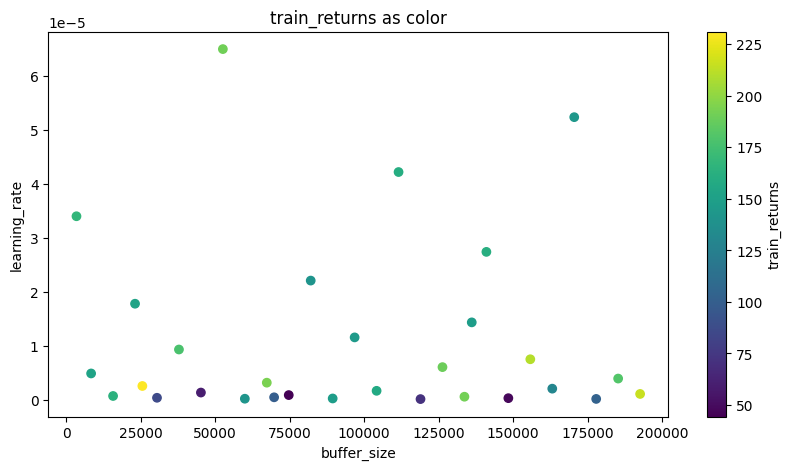

In [22]:
plot_returns_by_2_params(df, "buffer_size", "learning_rate")

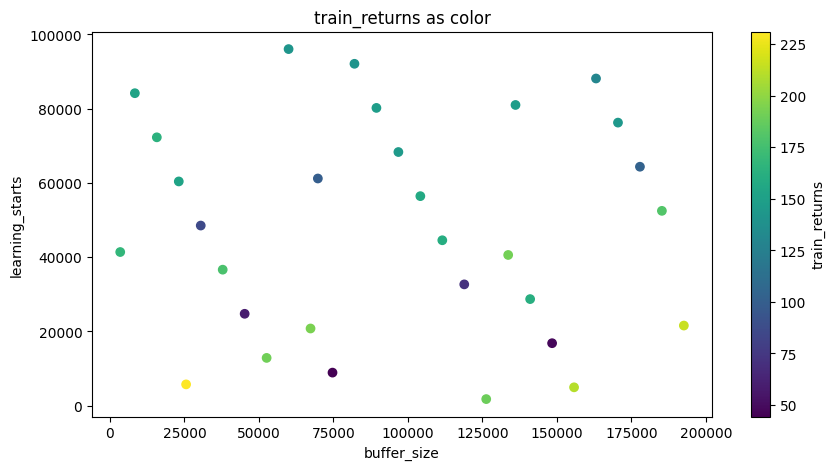

In [23]:
plot_returns_by_2_params(df, "buffer_size", "learning_starts")

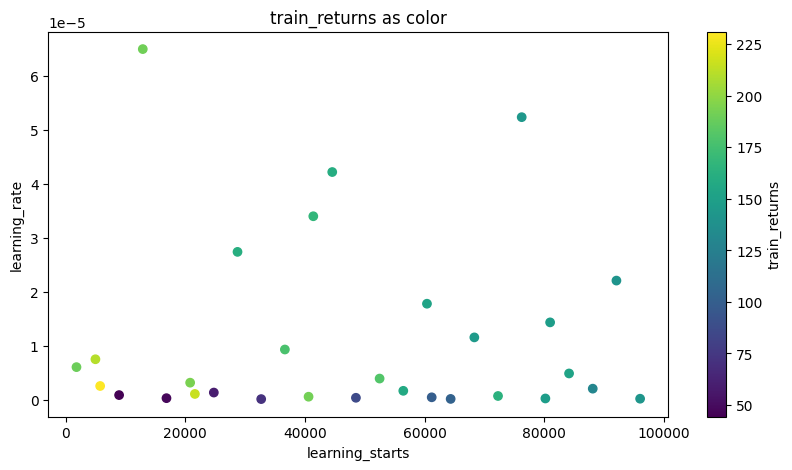

In [24]:
plot_returns_by_2_params(df, "learning_starts", "learning_rate")

While there are single good points, it seems that `learning_starts` of **1000**, `learning_rate` of about **4e-6**, and `buffer_size` of around **10_000** works the best.

<Axes: xlabel='buffer_size', ylabel='train_returns'>

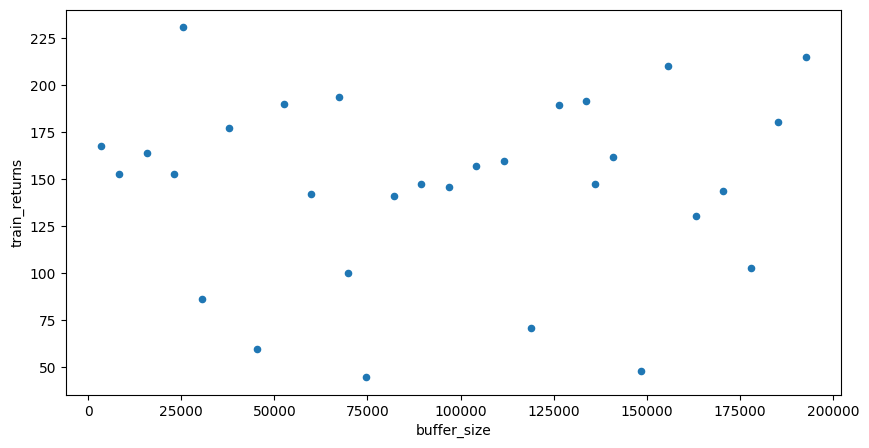

In [25]:
df[["buffer_size", "train_returns"]].plot(kind="scatter", x="buffer_size", y="train_returns")

<Axes: xlabel='learning_rate', ylabel='buffer_size'>

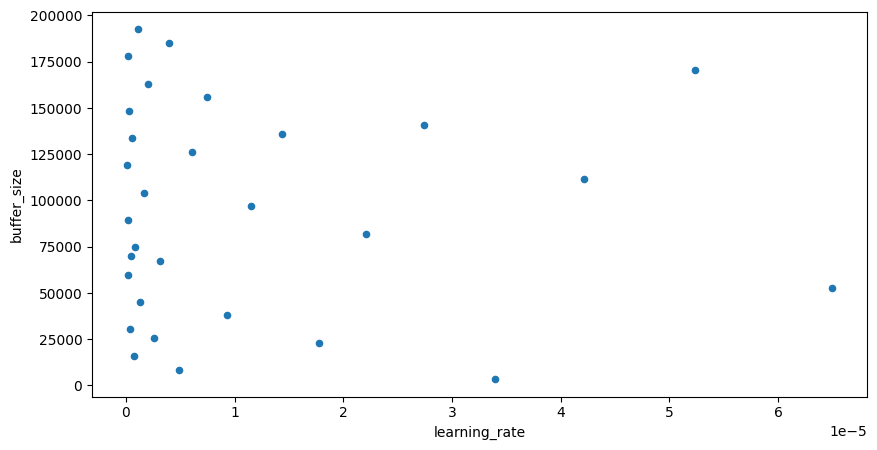

In [26]:
df[["buffer_size", "learning_rate"]].plot(kind="scatter", x="learning_rate", y="buffer_size")

<Axes: xlabel='learning_starts', ylabel='train_returns'>

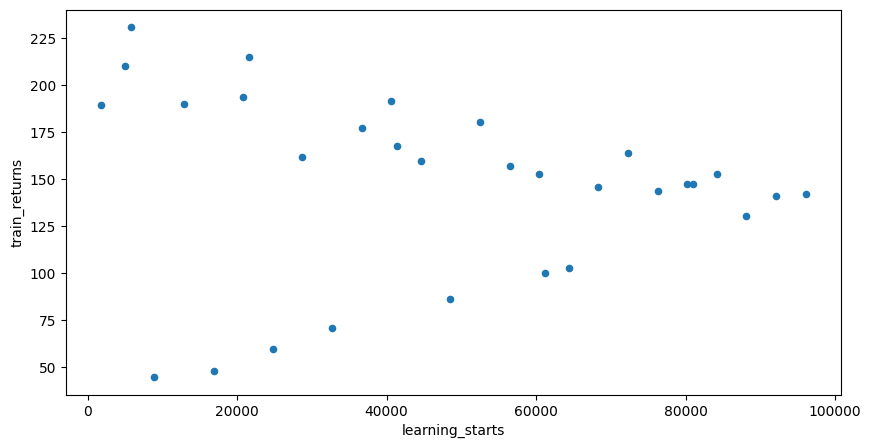

In [27]:
df[["learning_starts", "train_returns"]].plot(kind="scatter", x="learning_starts", y="train_returns")

<Axes: xlabel='learning_rate', ylabel='train_returns'>

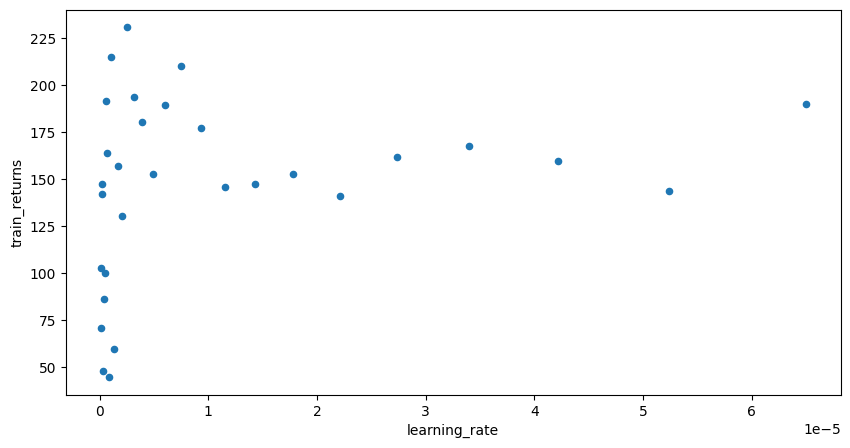

In [28]:
df[["learning_rate", "train_returns"]].plot(kind="scatter", x="learning_rate", y="train_returns")

In [29]:
df[["learning_rate", "train_returns"]]

,learning_rate,train_returns
0,3.162278e-06,193.512658
1,5.623413e-07,191.524390
2,1.778279e-05,152.443820
3,2.371374e-07,147.367021
4,7.498942e-06,210.125786
5,1.333521e-06,59.309392
6,4.216965e-05,159.800000
7,1.539927e-07,102.577320
8,4.869675e-06,152.634409
9,8.659643e-07,44.413408
